# Neural Network Forward Propagation Quiz Walkthrough

## Question 1: Calculating Neuron Activation in NumPy

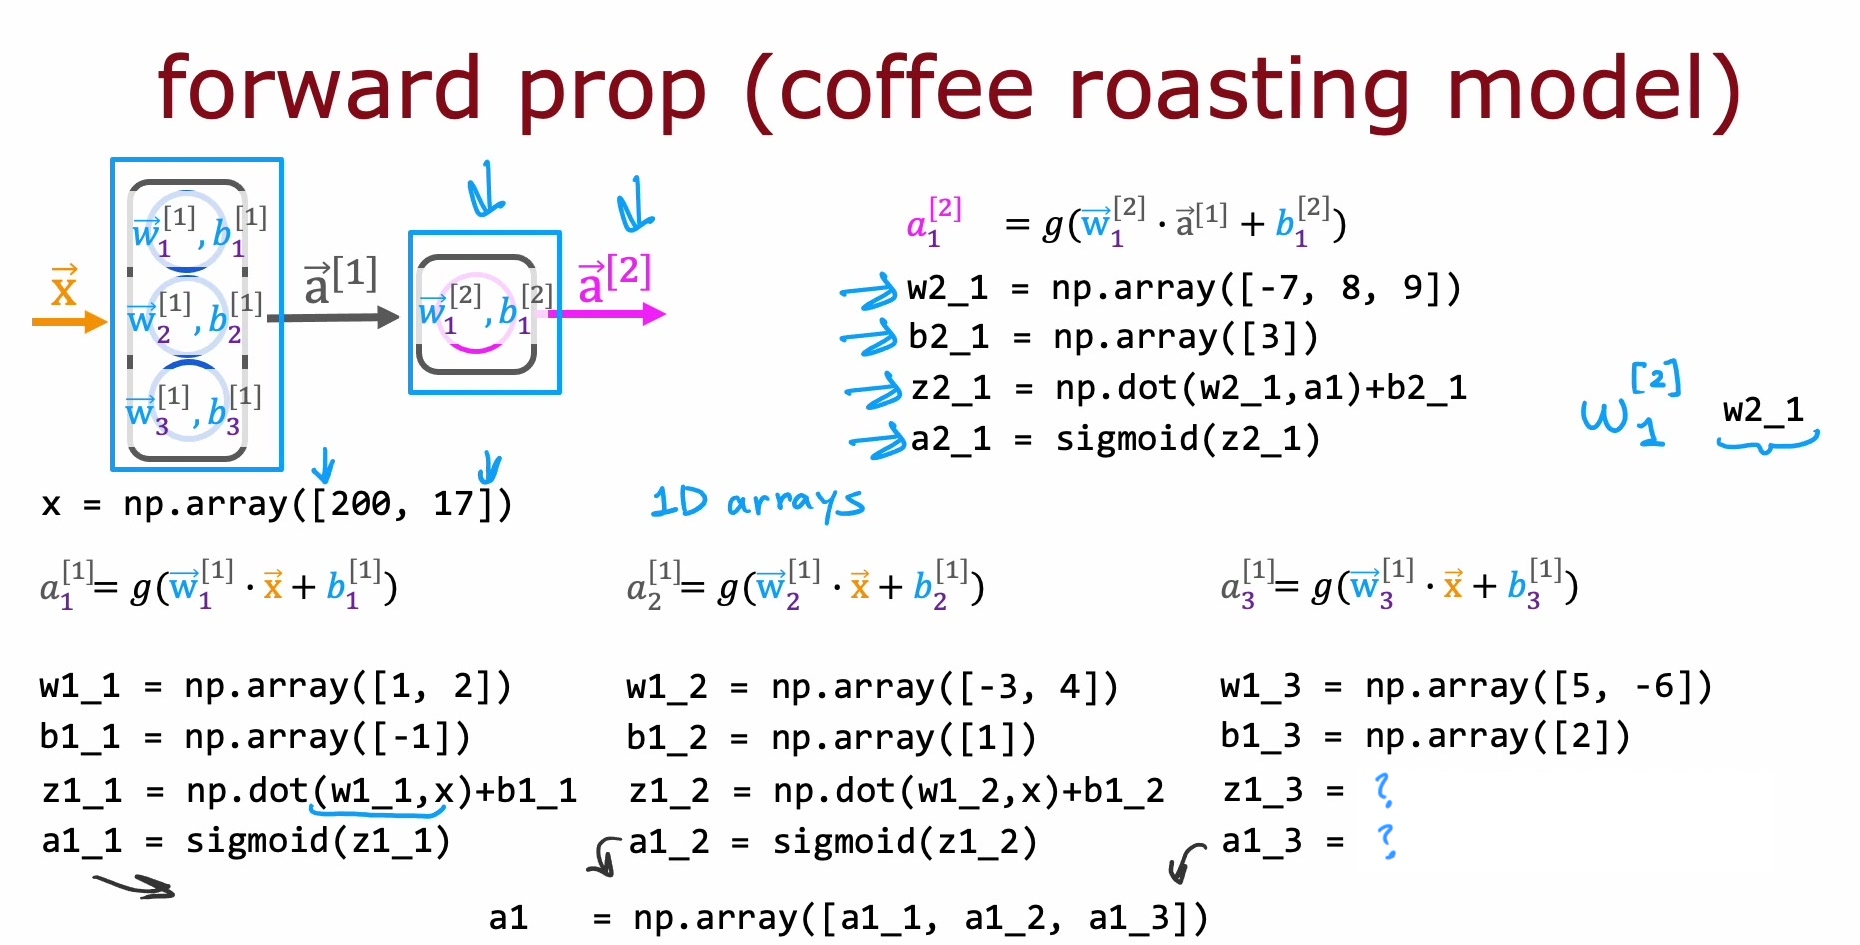

**Question:** According to the lecture, how do you calculate the activation of the third neuron in the first layer using NumPy?

**Options:**
- $z_{1,3} = np.dot(w_{1,3}, x) + b_{1,3}$, $a_{1,3} = sigmoid(z_{1,3})$
- $z_{1,3} = w_{1,3} \cdot x + b_{1,3}$, $a_{1,3} = sigmoid(z_{1,3})$
- $layer\_1 = Dense(units=3, activation='sigmoid')$, $a_{1,1} = layer\_1(x)$

### Correct Answer
✅ **Option 1:** $z_{1,3} = np.dot(w_{1,3}, x) + b_{1,3}$, $a_{1,3} = sigmoid(z_{1,3})$

### Why This is Correct

In neural networks, each neuron performs a two-step calculation:

1. **Linear combination:** $z = w \cdot x + b$ (weighted sum of inputs plus bias)
2. **Activation:** $a = g(z)$ (apply activation function, here sigmoid)

The notation $z_{1,3}$ means:
- First number (1): **Layer 1** (the input layer is often layer 0)
- Second number (3): **Neuron 3** in that layer

Using `np.dot(w, x)` is the correct NumPy way to compute the dot product between weight vector $w$ and input vector $x$.

### Why Other Options Are Incorrect

**Option 2** uses regular multiplication ($\cdot$) instead of dot product. In NumPy, $w_{1,3} \cdot x$ would try element-wise multiplication, which only works if arrays have the same shape (here $w$ has 2 elements, $x$ has 2 elements - actually this could work! Let me clarify...)

Actually, let's check carefully: If $w_{1,3}$ has shape (2,) and $x$ has shape (2,), then $w_{1,3} \cdot x$ does element-wise multiplication, returning another (2,) array - not a single number! So this would fail to produce the scalar $z$ value needed.

**Option 3** uses Keras-style high-level API. While this works in practice, the question specifically asks how to calculate using NumPy (lower-level implementation).

### Real-World Example

Imagine you're building a coffee roasting model with two inputs:
- $x_1 = 200$ (temperature in °F)
- $x_2 = 17$ (roasting time in minutes)

The third neuron in the first layer might learn to detect a specific pattern, like "high temperature but short time" for light roasts. It does this by:
1. Taking weighted sum: $(5 \times 200) + (-6 \times 17) + 2 = 1000 - 102 + 2 = 900$
2. Applying sigmoid: $\frac{1}{1+e^{-900}} \approx 1$ (strongly activated)

---



## Question 2: Weight Matrix Organization in NumPy

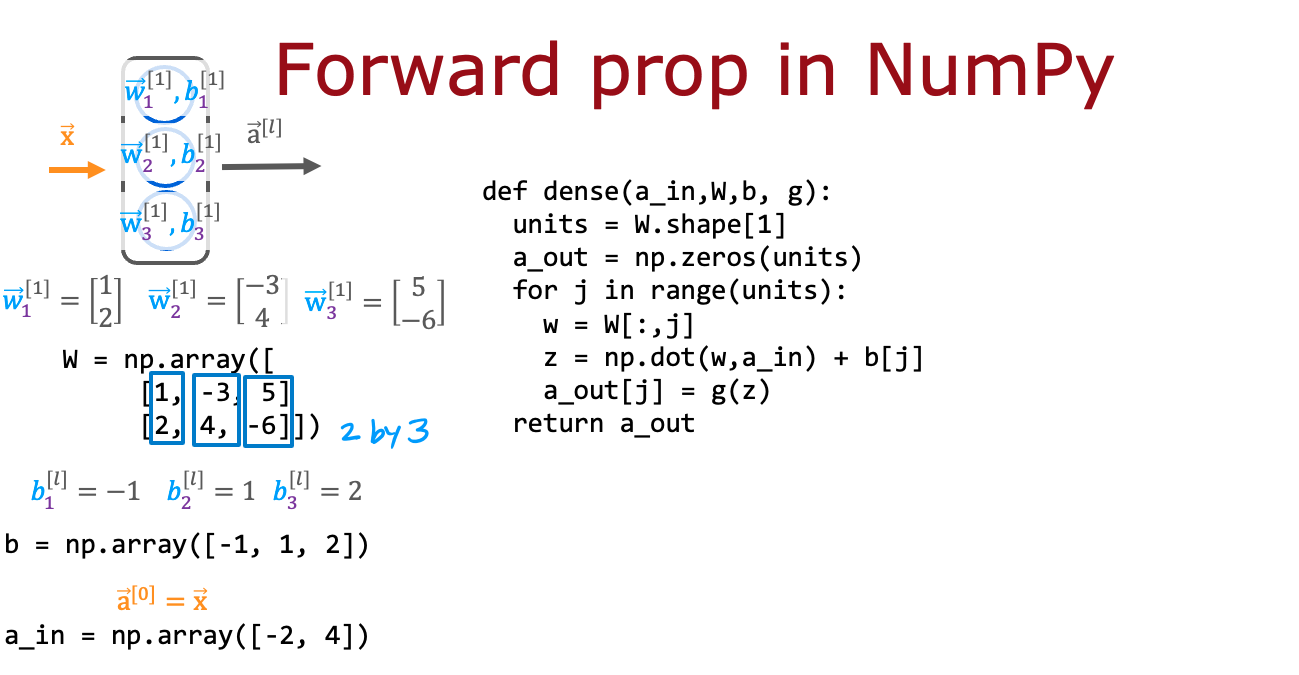

**Question:** According to the lecture, when coding up the numpy array W, where would you place the w parameters for each neuron?

**Options:**
- ✅ In the columns of W
- ❌ In the rows of W

### Correct Answer
✅ **In the columns of W**

### Why This is Correct

Looking at the code:
```python
def dense(a_in, W, b, g):
    units = W.shape[1]        # number of columns = number of neurons
    a_out = np.zeros(units)
    for j in range(units):
        w = W[:, j]            # taking column j = weights for neuron j
        z = np.dot(w, a_in) + b[j]
        a_out[j] = g(z)
    return a_out
```

The key insight is in `W[:, j]` - this extracts **all rows for column j**, which gives us the weight vector for neuron j. Therefore:
- Each **column** = one neuron's complete set of weights
- Each **row** = weights coming from a specific input feature to all neurons

### Why The Other Option Is Incorrect

If weights were stored in rows (`W[j, :]`), then:
- Each row would represent one neuron's weights
- But the code would need to change to `w = W[j, :]`
- This is actually equally valid mathematically, but the lecture specifically uses the **columns = neurons** convention

### Visual Example

For a layer with:
- 2 input features
- 3 neurons

```
W = [
    [w11, w12, w13],    # row 1: weights from feature 1 to neurons 1,2,3
    [w21, w22, w23]     # row 2: weights from feature 2 to neurons 1,2,3
]

Column 1: [w11, w21]ᵀ → weights for neuron 1
Column 2: [w12, w22]ᵀ → weights for neuron 2
Column 3: [w13, w23]ᵀ → weights for neuron 3
```



---

## Question 3: For Loop Iterations in Dense Layer

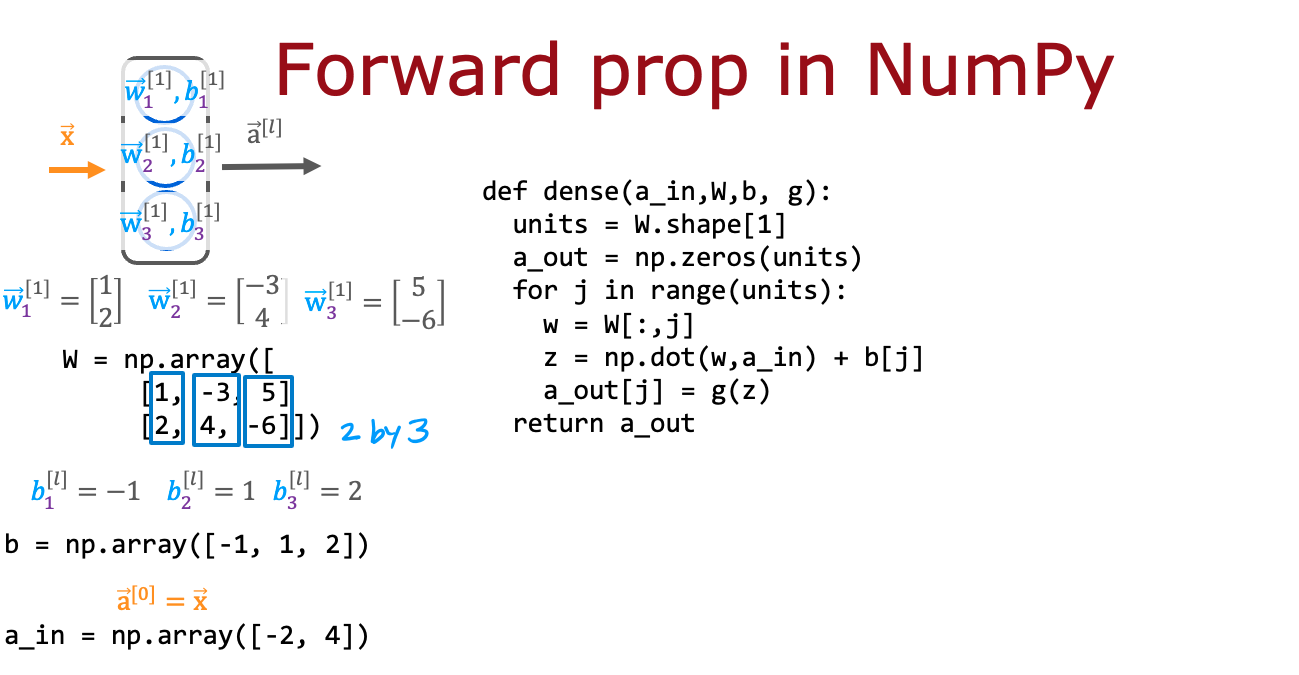

**Question:** For the code in the "dense" function, how many times does the code go through the "for loop"? Note that W has 2 rows and 3 columns.

**Options:**
- ✅ 3 times
- ❌ 2 times
- ❌ 6 times
- ❌ 5 times

### Correct Answer
✅ **3 times**

### Why This is Correct

```python
def dense(a_in, W, b, g):
    units = W.shape[1]        # W.shape = (2, 3), so W.shape[1] = 3
    a_out = np.zeros(units)   # creates array of size 3
    for j in range(units):    # range(3) = [0, 1, 2] → 3 iterations
        w = W[:, j]
        z = np.dot(w, a_in) + b[j]
        a_out[j] = g(z)
    return a_out
```

The loop iterates once for **each neuron** in the layer. With 3 columns (3 neurons), we get 3 iterations.

### Why Other Options Are Incorrect

- **2 times:** This would be true if we looped over rows (input features), but we loop over columns (neurons)
- **6 times:** This would be 2×3, perhaps confusing the total number of weights with number of neurons
- **5 times:** No relationship to the actual dimensions

### Understanding Layer Dimensions

For a neural network layer:
- **Input dimension:** Number of features from previous layer (here = 2)
- **Output dimension:** Number of neurons in current layer (here = 3)

The for loop processes each **output neuron** sequentially, calculating its activation based on all inputs.

### Real-World Connection

Think of a coffee roasting quality checker with:
- **Inputs:** Temperature, Time, Bean density (3 features)
- **Layer with 5 neurons:** Each neuron learns a different pattern (e.g., dark roast detector, burnt detector, etc.)

The loop would run 5 times - once for each quality detector neuron!

---

## Summary Table

| Question | Key Concept | Correct Answer |
|----------|------------|----------------|
| 1 | Neuron activation calculation | `np.dot(w, x) + b`, then `sigmoid(z)` |
| 2 | Weight matrix organization | Each neuron's weights in a **column** |
| 3 | Loop iterations = number of neurons | 3 iterations for 3 neurons |

**Key Takeaway:** Understanding these fundamentals helps you move from mathematical notation to working NumPy code, which is essential for building neural networks from scratch!
```